### 한국 관광공사 Tour API 크롤링

In [1]:
import requests

### 인증키

In [2]:
# 환경변수 불러오기
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# 에러 발생시 번갈아 가면서 시도해보기
# serviceKey = os.getenv('serviceKey_encoding')
serviceKey = os.getenv('serviceKey_decoding')

In [4]:
serviceKey

'kIaKnnCSdvczIIdHD545HNruHJHL/5tU6VaewO5wmgXz7rWCM/wDHbI49O73/PvUkrMtIxhcYdBJc1BkpzUPXQ=='

### 지역 코드 조회 (areaCode)

In [5]:
url = "http://apis.data.go.kr/B551011/KorService1/areaCode1"

In [6]:
params = {
    "serviceKey": serviceKey,
    "MobileOS": "ETC",
    "MobileApp": "AppTest",
    "_type": "json",
    "numOfRows": "20",
    "pageNo": "1"
}

#### API 요청

In [7]:
from pprint import pprint

In [8]:
# API 요청 및 응답
response = requests.get(url, params=params)
pprint(response.json())

{'response': {'body': {'items': {'item': [{'code': '1',
                                           'name': '서울',
                                           'rnum': 1},
                                          {'code': '2',
                                           'name': '인천',
                                           'rnum': 2},
                                          {'code': '3',
                                           'name': '대전',
                                           'rnum': 3},
                                          {'code': '4',
                                           'name': '대구',
                                           'rnum': 4},
                                          {'code': '5',
                                           'name': '광주',
                                           'rnum': 5},
                                          {'code': '6',
                                           'name': '부산',
                                           'rnu

In [9]:
response.json()['response']['body']['items']['item'][10]

{'rnum': 11, 'code': '33', 'name': '충청북도'}

### 지역기반 관광정보 조회

In [10]:
url = 'http://apis.data.go.kr/B551011/KorService1/areaBasedList1'

In [40]:
params = {
    "serviceKey": serviceKey,
    "MobileOS": "ETC",
    "MobileApp": "AppTest",
    "_type": "json",
    "areaCode": 33,
    "numOfRows": 756,
    "contentTypeId": 12,
    'cat1': 'A02',
}

#### API 요청

In [41]:
# API 요청 및 응답
response = requests.get(url, params=params)
pprint(response.json())

{'response': {'body': {'items': {'item': [{'addr1': '충청북도 옥천군 안내면 안내회남로 671',
                                           'addr2': '',
                                           'areacode': '33',
                                           'booktour': '0',
                                           'cat1': 'A02',
                                           'cat2': 'A0201',
                                           'cat3': 'A02010800',
                                           'contentid': '294369',
                                           'contenttypeid': '12',
                                           'cpyrhtDivCd': 'Type3',
                                           'createdtime': '20071126234108',
                                           'firstimage': 'http://tong.visitkorea.or.kr/cms/resource/29/3339929_image2_1.JPG',
                                           'firstimage2': 'http://tong.visitkorea.or.kr/cms/resource/29/3339929_image3_1.JPG',
                                   

#### contentid 추출

In [42]:
# image 파일이 있는 정보만 contentid 추출
contentids = []
responses = response.json()['response']['body']['items']['item']
for response in responses:
    if response['firstimage']:
        contentids.append(response['contentid'])

In [43]:
len(contentids)

419

### 서비스 분류코드 조회

#### 대분류

In [5]:
url = 'http://apis.data.go.kr/B551011/KorService1/categoryCode1'

In [16]:
params = {
    "serviceKey": serviceKey,
    "MobileOS": "ETC",
    "MobileApp": "AppTest",
    "_type": "json",
    "numOfRows": 10,
    # "pageNo": "1"
}

#### API 요청

In [17]:
# API 요청 및 응답
response = requests.get(url, params=params)
pprint(response.json())

{'response': {'body': {'items': {'item': [{'code': 'A01',
                                           'name': '자연',
                                           'rnum': 1},
                                          {'code': 'A02',
                                           'name': '인문(문화/예술/역사)',
                                           'rnum': 2},
                                          {'code': 'A03',
                                           'name': '레포츠',
                                           'rnum': 3},
                                          {'code': 'A04',
                                           'name': '쇼핑',
                                           'rnum': 4},
                                          {'code': 'A05',
                                           'name': '음식',
                                           'rnum': 5},
                                          {'code': 'B02',
                                           'name': '숙박',
                        

#### 중분류

In [62]:
params = {
    "serviceKey": serviceKey,
    "MobileOS": "ETC",
    "MobileApp": "AppTest",
    "_type": "json",
    "numOfRows": 10,
    "contentTypeId": 12,
    "cat1": 'A02',
    # "pageNo": "1"
}

#### API 요청

In [63]:
# API 요청 및 응답
response = requests.get(url, params=params)
pprint(response.json())

{'response': {'body': {'items': {'item': [{'code': 'A0201',
                                           'name': '역사관광지',
                                           'rnum': 1},
                                          {'code': 'A0202',
                                           'name': '휴양관광지',
                                           'rnum': 2},
                                          {'code': 'A0203',
                                           'name': '체험관광지',
                                           'rnum': 3},
                                          {'code': 'A0204',
                                           'name': '산업관광지',
                                           'rnum': 4},
                                          {'code': 'A0205',
                                           'name': '건축/조형물',
                                           'rnum': 5}]},
                       'numOfRows': 5,
                       'pageNo': 1,
                       'totalCount': 5},
      

#### 소분류

In [6]:
params = {
    "serviceKey": serviceKey,
    "MobileOS": "ETC",
    "MobileApp": "AppTest",
    "_type": "json",
    "numOfRows": 10,
    "contentTypeId": 12,
    "cat1": 'A02',
    "cat2": 'A0201',
    # "pageNo": "1"
}

In [9]:
# API 요청 및 응답
response = requests.get(url, params=params)
pprint(response.json())

{'response': {'body': {'items': {'item': [{'code': 'A02010100',
                                           'name': '고궁',
                                           'rnum': 1},
                                          {'code': 'A02010200',
                                           'name': '성',
                                           'rnum': 2},
                                          {'code': 'A02010300',
                                           'name': '문',
                                           'rnum': 3},
                                          {'code': 'A02010400',
                                           'name': '고택',
                                           'rnum': 4},
                                          {'code': 'A02010500',
                                           'name': '생가',
                                           'rnum': 5},
                                          {'code': 'A02010600',
                                           'name': '민속마을',

### 공통정보조회

In [44]:
url = 'http://apis.data.go.kr/B551011/KorService1/detailCommon1'

#### API 요청

In [45]:
# API 요청 및 응답
# 앞서 추출한 419개의 contentid 로 공통정보조회
response_dict = {}
i = 1
# API 한도 1,000건으로 인해 일부만 조회
for contentid in contentids:
    params = {
        "serviceKey": serviceKey,
        "MobileOS": "ETC",
        "MobileApp": "AppTest",
        "_type": "json",
        "contentId": contentid,
        "defaultYN": "Y",
        "firstImageYN": "Y",
        "areacodeYN": "Y",
        "catcodeYN": "Y",
        "addrinfoYN": "Y",
        "overviewYN": "Y",
        "numOfRows": 10,
        "pageNo": 1,
    }

    try:
        response = requests.get(url, params=params)

        response_dict[contentid] = response.json()['response']['body']['items']['item'][0]
        keys_to_keep = ['contentid', 'contenttypeid', 'title', 'cat1', 'cat2', 'addr1', 'overview', 'firstimage']
        filtered_dict = {
            key: {k: v for k, v in inner_dict.items() if k in keys_to_keep}
            for key, inner_dict in response_dict.items()
        }
        print(f'데이터 추가에 성공하였습니다. 현재 추가 데이터는 {i}개 입니다.')
        i += 1
    except:
        print(f'데이터 추가에 실패하였습니다. 해당 데이터는 {contentid} 입니다.')

데이터 추가에 성공하였습니다. 현재 추가 데이터는 1개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 2개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 3개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 4개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 5개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 6개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 7개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 8개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 9개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 10개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 11개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 12개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 13개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 14개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 15개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 16개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 17개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 18개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 19개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 20개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 21개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 22개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 23개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 24개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 25개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 26개 입니다.
데이터 추가에 성공하였습니다. 현재 추가 데이터는 27개 입니다.
데이터 추가에 성공

In [46]:
response_dict[contentids[0]]

{'contentid': '294369',
 'contenttypeid': '12',
 'title': '가산사',
 'createdtime': '20071126234108',
 'modifiedtime': '20250220112256',
 'tel': '',
 'telname': '',
 'homepage': '<a href="https://tour.chungbuk.go.kr/www/selectTourCntnts.do?key=60&searchMainSe=ATTR&tourNo=393" target="_blank" title="새창 : 홈페이지로 이동">https://tour.chungbuk.go.kr/</a>',
 'booktour': '0',
 'firstimage': 'http://tong.visitkorea.or.kr/cms/resource/29/3339929_image2_1.JPG',
 'firstimage2': 'http://tong.visitkorea.or.kr/cms/resource/29/3339929_image3_1.JPG',
 'cpyrhtDivCd': 'Type3',
 'areacode': '33',
 'sigungucode': '5',
 'cat1': 'A02',
 'cat2': 'A0201',
 'cat3': 'A02010800',
 'addr1': '충청북도 옥천군 안내면 안내회남로 671',
 'addr2': '',
 'zipcode': '29005',
 'overview': '가산사는 대한불교 조계종 제5교구 본사인 법주사의 말사이다. 임진왜란 때 의병과 의승군이 활동했던 사찰 가산사는 신라시대 때 창건된 것으로 전해진다. 가산사는 임진왜란 당시 풍전등화와 같은 민족을 구하기 위해 많은 의승군과 의병이 훈련했던 호국정신이 깃들어 있는 곳이다. 임진왜란 당시 활약했던 의병장들로는 곽재우, 고경명, 정문부, 조헌 등이 있고, 의승군으로는 서산, 사명, 영규, 처영, 신열, 법정 스님 등이 있다. 이 가운데 영규대사는 서산대사가 승군의 총

In [47]:
filtered_dict[contentids[0]]

{'contentid': '294369',
 'contenttypeid': '12',
 'title': '가산사',
 'firstimage': 'http://tong.visitkorea.or.kr/cms/resource/29/3339929_image2_1.JPG',
 'cat1': 'A02',
 'cat2': 'A0201',
 'addr1': '충청북도 옥천군 안내면 안내회남로 671',
 'overview': '가산사는 대한불교 조계종 제5교구 본사인 법주사의 말사이다. 임진왜란 때 의병과 의승군이 활동했던 사찰 가산사는 신라시대 때 창건된 것으로 전해진다. 가산사는 임진왜란 당시 풍전등화와 같은 민족을 구하기 위해 많은 의승군과 의병이 훈련했던 호국정신이 깃들어 있는 곳이다. 임진왜란 당시 활약했던 의병장들로는 곽재우, 고경명, 정문부, 조헌 등이 있고, 의승군으로는 서산, 사명, 영규, 처영, 신열, 법정 스님 등이 있다. 이 가운데 영규대사는 서산대사가 승군의 총책임을 맡기 전 자발적으로 승군을 조직한 최초의 승장이다. 가산사 일대는 영규대사와 조헌 선생이 의승군과 의병을 훈련하고 군영으로 사용했던 곳으로 큰 역사적 의의를 지니고 있다.\n청주성 탈환에 큰 공헌을 한 영규대사와 조헌 선생은 금산의 연곤평전투에서 순절했는데 국가에서는 그 충절을 기리기 위하여 가산사를 호국사찰로 지정하고 진영을 봉안하여 제향을 올리게 하였다. 하지만 일제강점기에 항일운동의 중심지가 될 것을 염려한 조선총독부는 그간 전해오던 두 의병장의 영정을 강탈하고 불온사찰이라 지목하여 가산사를 탄압하기도 했다. 오늘날 옥천군에서는 국난극복에 앞장섰던 충의열사들을 위해 해마다 가산사에서 제사를 올리고 있다.'}

In [48]:
for response in response_dict.values():
    print(response['firstimage'])

http://tong.visitkorea.or.kr/cms/resource/29/3339929_image2_1.JPG
http://tong.visitkorea.or.kr/cms/resource/40/3340640_image2_1.JPG
http://tong.visitkorea.or.kr/cms/resource/73/3334573_image2_1.JPG
http://tong.visitkorea.or.kr/cms/resource/36/3355336_image2_1.JPG
http://tong.visitkorea.or.kr/cms/resource/35/3338935_image2_1.JPG
http://tong.visitkorea.or.kr/cms/resource/66/3334566_image2_1.JPG
http://tong.visitkorea.or.kr/cms/resource/49/3349149_image2_1.JPG
http://tong.visitkorea.or.kr/cms/resource/30/3373830_image2_1.jpg
http://tong.visitkorea.or.kr/cms/resource/18/3338918_image2_1.JPG
http://tong.visitkorea.or.kr/cms/resource/27/3348727_image2_1.JPG
http://tong.visitkorea.or.kr/cms/resource/22/3350222_image2_1.JPG
http://tong.visitkorea.or.kr/cms/resource/76/2648476_image2_1.bmp
http://tong.visitkorea.or.kr/cms/resource/18/2770118_image2_1.jpg
http://tong.visitkorea.or.kr/cms/resource/19/731019_image2_1.jpg
http://tong.visitkorea.or.kr/cms/resource/03/3334503_image2_1.JPG
http://tong

### 수집한 이미지 (firstimage) 로컬 저장

In [49]:
import os
import requests

# 저장할 폴더 경로 설정
save_folder = "image"
if not os.path.exists(save_folder):
    os.makedirs(save_folder)  # 폴더가 없으면 생성

for response in response_dict.values():
    image_url = response['firstimage']
    contentid = response['contentid']
    _, ext = os.path.splitext(image_url)
    
    # 확장자가 '.jpg'가 아니면 무조건 '.jpg'로 지정
    if ext.lower() != '.jpg':
        ext = '.jpg'
    
    # 파일 경로를 폴더와 파일명으로 지정
    file_path = os.path.join(save_folder, f"tour_image_{contentid}{ext}")
    
    try:
        r = requests.get(image_url)
        r.raise_for_status()  # 상태 코드가 200이 아니면 예외 발생
        with open(file_path, 'wb') as f:
            f.write(r.content)
        print(f"Saved {file_path}")
    except Exception as e:
        print(f"Error downloading image for contentid {contentid}: {e}")


Saved image\tour_image_294369.JPG
Saved image\tour_image_294390.JPG
Saved image\tour_image_127241.JPG
Saved image\tour_image_527227.JPG
Saved image\tour_image_1432440.JPG
Saved image\tour_image_1431823.JPG
Saved image\tour_image_2987654.JPG
Saved image\tour_image_1955985.jpg
Saved image\tour_image_1955991.JPG
Saved image\tour_image_1682800.JPG
Saved image\tour_image_1682895.JPG
Saved image\tour_image_2648488.jpg
Saved image\tour_image_2770109.jpg
Saved image\tour_image_791697.jpg
Saved image\tour_image_1434605.JPG
Saved image\tour_image_791770.jpg
Saved image\tour_image_1437035.JPG
Saved image\tour_image_1435965.JPG
Saved image\tour_image_1435934.JPG
Saved image\tour_image_1434629.JPG
Saved image\tour_image_1436057.jpg
Saved image\tour_image_1677831.JPG
Saved image\tour_image_704505.JPG
Saved image\tour_image_1434911.JPG
Saved image\tour_image_1436034.JPG
Saved image\tour_image_1678532.JPG
Saved image\tour_image_793086.jpg
Saved image\tour_image_793203.jpg
Saved image\tour_image_127289

#### 파일 저장 성공 여부 확인

In [50]:
import os

save_folder = "image"

if os.path.exists(save_folder):
    files = os.listdir(save_folder)
    file_count = len(files)
    print(f"{save_folder} 폴더에는 {file_count}개의 파일이 있습니다.")
else:
    print(f"{save_folder} 폴더가 존재하지 않습니다.")

image 폴더에는 419개의 파일이 있습니다.


#### 이미지 파일 jpeg 확장자로 변환

In [51]:
import os
from PIL import Image

def convert_to_supported_format(image_path, output_format='jpeg'):
    """
    주어진 이미지 파일을 지원되는 포맷으로 변환합니다.
    output_format 인자는 'jpeg', 'png', 'gif', 'webp' 중 하나여야 합니다.
    """
    with Image.open(image_path) as img:
        # JPEG 변환 시 알파 채널이 있는 경우 'RGB'로 변환
        if output_format.lower() == 'jpeg':
            img = img.convert('RGB')
        new_image_path = os.path.splitext(image_path)[0] + f'.{output_format}'
        img.save(new_image_path, output_format.upper())
    return new_image_path

In [52]:
import os
from glob import glob

# 이미지 폴더 경로 지정
image_folder = "image"

# 폴더 내의 모든 .jpg와 .JPG 파일을 찾습니다.
image_files = glob(os.path.join(image_folder, "*.[jJ][pP][gG]"))

# 각 이미지 파일을 지원되는 포맷으로 변환하고, 변환된 파일 경로를 리스트에 저장
converted_files = []
try:
    for image_path in image_files:
        supported_image_path = convert_to_supported_format(image_path, output_format='jpeg')
        converted_files.append(supported_image_path)
except Exception as e:
    print(f"이미지 변환 중 오류 발생: {e}")
    print("에러가 발생한 이미지 파일:", image_path)

# 최종적으로 변환된 .jpeg 파일의 개수만 출력
print("변환된 .jpeg 파일 개수:", len(converted_files))

변환된 .jpeg 파일 개수: 419


In [53]:
# 기존 jpg 파일 삭제
for image_path in image_files:
    os.remove(image_path)

#### 관광지 정보 파일 저장

In [ ]:
import pandas as pd

pd.DataFrame(data=filtered_dict,
             index=['contentid', 'contenttypeid', 'title', 'cat1', 'cat2', 'addr1', 'overview', 'firstimage']).T.to_csv('tour_data.csv', index=False)

---

In [56]:
import pandas as pd

# cat1 이 A01, A02, A03 인 데이터만 추출
tour_data = pd.read_csv('tour_data.csv')
tour_data

,contentid,contenttypeid,title,cat1,cat2,addr1,overview,firstimage
0,294369,12,가산사,A02,A0201,충청북도 옥천군 안내면 안내회남로 671,가산사는 대한불교 조계종 제5교구 본사인 법주사의 말사이다. 임진왜란 때 의병과 의...,http://tong.visitkorea.or.kr/cms/resource/29/3...
1,294390,12,가섭사,A02,A0201,충청북도 음성군 음성읍 가섭길 494,가섭사는 석가모니의 10대 제자 중 하나인 가섭존자의 이름을 딴 고려 후기의 사찰이...,http://tong.visitkorea.or.kr/cms/resource/40/3...
2,127241,12,각연사(괴산),A02,A0201,충청북도 괴산군 칠성면 각연길 451,신라 법흥왕 때에 유일대사가 현재의 충북 괴산군 칠성면 쌍곡리 근처에 터를 잡고 절...,http://tong.visitkorea.or.kr/cms/resource/73/3...
3,527227,12,강천사(제천),A02,A0201,충청북도 제천시 송학면 옥천3길 56-10,학이 둥지를 튼다는 송학산에 자리 잡은 제천의 강천사는 송학산 정상 바로 아래에 자...,http://tong.visitkorea.or.kr/cms/resource/36/3...
4,1432440,12,개심사 목조여래좌상과 목조관음보살좌상,A02,A0201,충청북도 괴산군 괴산읍 역말길 22,개심사에는 조선시대에 만들어진 나무로 된 여래좌상과 관음보살좌상이 모셔져 있다. 원...,http://tong.visitkorea.or.kr/cms/resource/35/3...
...,...,...,...,...,...,...,...,...
414,1627338,12,황강 영당 및 수암사,A02,A0201,충청북도 제천시 한수면 미륵송계로 1801,황강 영당은 조선 주자학의 대가인 송시열과 그의 제자인 권상하와 권상하의 제자 한원...,http://tong.visitkorea.or.kr/cms/resource/98/3...
415,1954449,12,회인향교,A02,A0201,충청북도 보은군 회인면 부수1길 31-11,회인향교는 조선 세 종때 창건되었으나 선조 때 임진왜란시 재화로 불타자 보은향교와 ...,http://tong.visitkorea.or.kr/cms/resource/32/3...
416,2891306,12,(주)마치공작소,A02,A0203,충청북도 충주시 마치4길 9-6,주식회사 마치공작소는 충주의 서부쪽에 위치한 옛 말죽거리인 마치마을에 위치한 공작소...,http://tong.visitkorea.or.kr/cms/resource/48/2...
417,2617346,12,CJ 블로썸 캠퍼스 (CJ제일제당),A02,A0204,충청북도 진천군 진천읍 씨제이로 110,CJ블로썸캠퍼스는 디지털 첨단 기술을 바탕으로 생산 및 물류를 아우르는 장소로 CJ...,http://tong.visitkorea.or.kr/cms/resource/36/2...


In [64]:
# cat2 값을 각 값에 해당하는 한글로 변경
# A0201 : 역사관광지, A0202 : 휴양관광지, A0203 : 체험관광지, A0204 : 산업관광지, A0205 : 건축/조형물

tour_data['cat2'] = tour_data['cat2'].map({
    'A0201': '역사관광지',
    'A0202': '휴양관광지',
    'A0203': '체험관광지',
    'A0204': '산업관광지',
    'A0205': '건축/조형물'
})

In [67]:
tour_data = tour_data.to_csv('tour_data.csv', index=False)

In [75]:
# 데이터프레임 표시 제한 해제
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

tour_data = pd.read_csv('tour_data.csv')
tour_data[['contentid', 'title']]

,contentid,title
0,294369,가산사
1,294390,가섭사
2,127241,각연사(괴산)
3,527227,강천사(제천)
4,1432440,개심사 목조여래좌상과 목조관음보살좌상
5,1431823,개심사(괴산)
6,2987654,건지마을
7,1955985,검암서원
8,1955991,계담서원
9,1682800,고산사 석조관음보살좌상


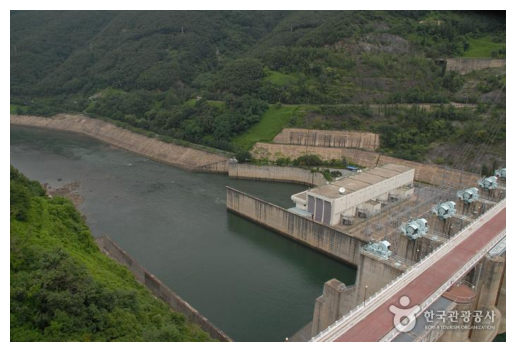

In [81]:
# image 폴더의 이미지 파일 불러오기
import os
from PIL import Image
import matplotlib.pyplot as plt

# 이미지 파일 경로
image_path = f'image/tour_image_{tour_data.loc[387, 'contentid']}.jpeg'

# 이미지 파일 불러오기
img = Image.open(image_path)

# 이미지 파일 출력
plt.imshow(img)
plt.axis('off')
plt.show()

In [82]:
tour_data[tour_data['contentid'] == 126766]

,contentid,contenttypeid,title,cat1,cat2,addr1,overview,firstimage
72,126766,12,도담삼봉 음악분수,A02,건축/조형물,충청북도 단양군 매포읍 삼봉로 644-13,도담삼봉 주변에는 있는 음악분수대는 1997년 11월부터 7억여 원의 사업비를 들여...,http://tong.visitkorea.or.kr/cms/resource/44/5...
